# Bài 4: Phân cụm phân cấp và Giảm chiều dữ liệu PCA
Ứng dụng thuật toán Phân cụm phân cấp (Hierarchical Clustering) và PCA để phân nhóm khách hàng tín dụng.

---

## I. Giải thích về PCA (Principal Component Analysis)

### 1. Khái niệm
PCA là phương pháp biến đổi giúp giảm số lượng lớn các biến có tương quan với nhau thành một tập ít các biến mới (gọi là các thành phần chính) sao cho:
* Các biến mới là tổ hợp tuyến tính của các biến cũ.
* Các biến mới không còn tương quan lẫn nhau.
* Giữ lại được nhiều nhất lượng thông tin (phương sai) từ tập dữ liệu ban đầu.

**Ví dụ:** Tưởng tượng việc chụp ảnh một con lạc đà từ các góc độ khác nhau. Mỗi góc chụp (trục tọa độ) sẽ cho ta những lượng thông tin khác nhau. PCA giúp ta tìm ra góc chụp mà ở đó ta thấy rõ hình dáng con lạc đà nhất với ít số chiều nhất.

### 2. Đặc tính của PCA
* **Giảm số chiều:** Giúp trực quan hóa dữ liệu có quá nhiều chiều thông tin (nhiều biến).
* **Maximize Variability:** Xoay trục tọa độ để đảm bảo trục mới giữ lại độ biến thiên của dữ liệu lớn nhất.
* **Tạo biến mới (Factor):** Các thành phần chính là sự kết hợp toán học từ các biến gốc.
* **Khám phá thông tin:** Giúp phát hiện các đặc điểm tiềm ẩn mà ở không gian cũ bị che khuất.

### 3. Mô hình toán học
Thành phần chính đầu tiên ($PC_1$) được xây dựng sao cho nó giải thích được lượng biến thiên lớn nhất của dữ liệu:
$$PC_1 = a_1X_1 + a_2X_2 + ... + a_kX_k$$
Các thành phần tiếp theo ($PC_2, PC_3, ...$) sẽ trực giao (không tương quan) với các thành phần trước đó và giải thích phần biến thiên còn lại.

---

## II. Thực hành Phân cụm khách hàng tín dụng (Credit Card Clustering)

### 1. Khai báo thư viện và nạp dữ liệu khách hàng
Sử dụng bộ dữ liệu `CC GENERAL.csv` chứa thông tin về thói quen sử dụng thẻ tín dụng của khoảng 9,000 khách hàng.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc
import os


# Sử dụng os.path.join để đảm bảo hoạt động trên các hệ điều hành khác nhau
base_dir = os.path.dirname(os.path.abspath('__file__'))
csv_path = os.path.join('Lab3_2224802010279_LeVanHoang', 'data', 'CC GENERAL.csv')

try:
    print(f"Đang nạp dữ liệu từ: {csv_path}")
    df = pd.read_csv(csv_path)
except FileNotFoundError:
  
    print("Thử tìm kiếm trong thư mục hiện tại...")
    csv_path = os.path.join('data', 'CC GENERAL.csv')
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Vẫn không thấy file tại {csv_path}.")
        raise

# Tiền xử lý:
# 1. Bỏ cột CUST_ID (mã khách hàng, không dùng để phân cụm)
X = df.drop('CUST_ID', axis=1)

# 2. Xử lý giá trị bị thiếu (Missing values) - Sử dụng ffill() thay cho fillna(method='ffill')
X = X.ffill()

# 3. Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Chuẩn hóa theo phương pháp Normalize
X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized)

print("Dữ liệu CC GENERAL đã được nạp thành công!")
display(X_normalized.head())


Đang nạp dữ liệu từ: Lab3_2224802010279_LeVanHoang\data\CC GENERAL.csv
Thử tìm kiếm trong thư mục hiện tại...
Dữ liệu CC GENERAL đã được nạp thành công!


C:\Users\ACER\AppData\Local\Temp\ipykernel_13308\2688793776.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-0.312038,-0.106331,-0.181129,-0.152156,-0.148808,-0.198985,-0.343796,-0.289304,-0.301518,-0.287892,-0.202942,-0.217975,-0.409413,-0.225497,-0.130160,-0.224036,0.153753
1,0.219928,0.037539,-0.131224,-0.099751,-0.127038,0.728177,-0.341439,-0.189662,-0.256269,0.160403,0.030762,-0.165387,0.192455,0.228782,0.024353,0.065458,0.100798
2,0.126684,0.146785,-0.030505,0.030851,-0.128792,-0.132251,0.359775,0.757449,-0.259805,-0.191342,-0.134881,-0.030888,0.234046,-0.108741,-0.028363,-0.148900,0.102189
3,0.020571,-0.426063,0.097223,0.228832,-0.190449,-0.154451,-0.424878,-0.167299,-0.384185,-0.108474,-0.138062,-0.231084,0.346093,-0.250827,-0.041942,-0.220185,0.151110
4,-0.151630,0.218959,-0.195282,-0.146778,-0.192118,-0.197278,-0.428601,-0.168765,-0.387551,-0.285424,-0.201202,-0.233109,-0.382671,-0.153993,-0.110323,-0.222114,0.152435


### 2. PCA - Giảm số chiều dữ liệu (Dễ dàng trực quan hóa)
Dữ liệu ban đầu có rất nhiều cột đặc trưng. Chúng ta sử dụng PCA để giảm xuống còn **2 thành phần chính (2D)** giúp dễ dàng vẽ được biểu đồ.

In [2]:
pca = PCA(n_components=2)
X_principal = pca.fit_transform(X_normalized)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']

print("Dữ liệu sau khi giảm xuống 2 chiều (P1, P2):")
display(X_principal.head())

Dữ liệu sau khi giảm xuống 2 chiều (P1, P2):


,P1,P2
0,-0.489949,-0.679976
1,-0.519099,0.544827
2,0.330633,0.268879
3,-0.481656,-0.097611
4,-0.563512,-0.482506


### 3. Biểu đồ Dendrogram - Xác định số cụm tối ưu
Dendrogram giúp ta quan sát cách các điểm dữ liệu hợp nhất lại với nhau. Cắt ngang biểu đồ này ở một mức độ biến thiên hợp lý để tìm ra số cụm `k` lý tưởng.

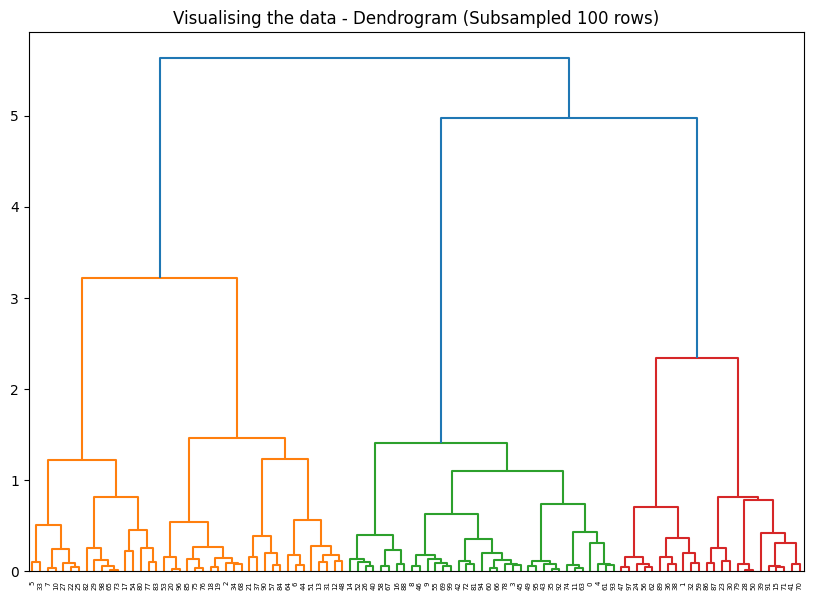

In [5]:
# Lấy mẫu 100 hàng đầu để vẽ Dendrogram cho rõ ràng, không bị chồng lấn
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("Visualising the data - Dendrogram (Subsampled 100 rows)")
# Sử dụng 100 hàng đầu
dend = shc.dendrogram(shc.linkage(X_principal.head(100), method='ward'))
plt.axhline(y=6, color='r', linestyle='--') 
plt.show()


### 4. Phân cụm phân cấp (Agglomerative Clustering)
Chúng ta thử thay đổi số cụm `n_clusters` (ví dụ `k=2, 3, 4`) để quan sát kết quả tối ưu. Phân cụm dạng tổng hợp sẽ coi mỗi điểm là 1 cụm ban đầu rồi gộp dần lại.

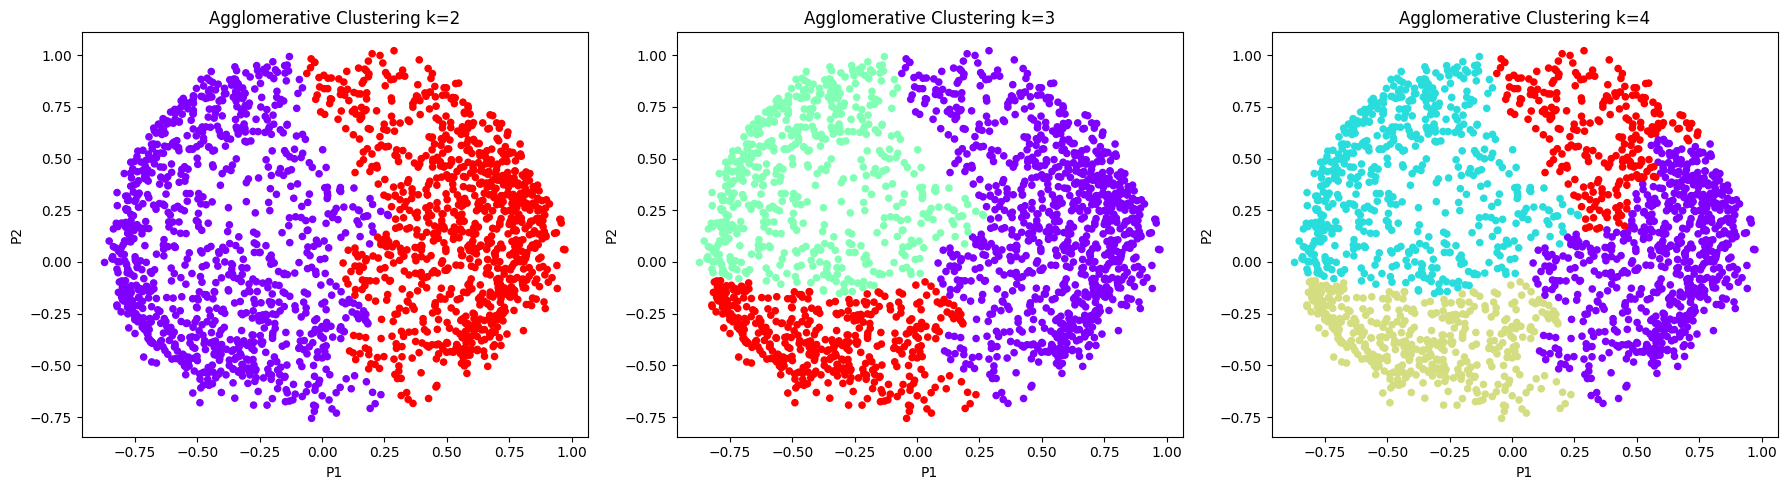

In [6]:
# Lọc ra 2000 bản ghi đầu để chạy mô hình thực tế (tránh treo máy)
X_sub = X_principal.head(2000)

k_values = [2, 3, 4]
plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_sub)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X_sub['P1'], X_sub['P2'], c=labels, cmap='rainbow', s=20)
    plt.title(f'Agglomerative Clustering k={k}')
    plt.xlabel('P1')
    plt.ylabel('P2')

plt.tight_layout()
plt.show()